# Cloud Probability API — Demo
Estimación de probabilidad de nubosidad sobre **Villa Carlos Paz, Argentina**
usando datos históricos de Sentinel-2 (COPERNICUS/S2_CLOUD_PROBABILITY).

In [ ]:
# Instalar dependencias (solo necesario en Colab)
# !pip install earthengine-api geemap matplotlib

In [3]:
import ee

# Autenticación: ejecutar una sola vez por sesión
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-test-satelite-img-proc')  # reemplazar con tu proyecto GEE

In [4]:
from datetime import datetime
from cloud_probability_api import CloudProbabilityAPI

# Región: Villa Carlos Paz (bounding box)
region = ee.Geometry.Rectangle([-64.55, -31.45, -64.35, -31.30])

api = CloudProbabilityAPI(region=region, start_year=2019, end_year=2024)

## 1. Probabilidad de nubosidad para una fecha objetivo

In [4]:
target = datetime(2024, 8, 15)   # 15 de enero

prob = api.get_cloud_probability(target, window_days=15)
usable_prob = api.get_usable_image_probability(target, window_days=3, max_clouds=10.0)
print(f"Nubosidad esperada el {target.strftime('%d %b')}:")
print(f"  Media : {prob['mean']:.1f}%")
print(f"  Std   : {prob['std']:.1f}%")

print(f"  P25 (Días más despejados) : {prob['p25']:.1f}%")
print(f"  Mediana (Lo típico)       : {prob['median']:.1f}%")
print(f"  P75 (Días más nublados)   : {prob['p75']:.1f}%")
print("-" * 40)
print(f"  Prob. de imagen útil (≤20% nubes): {usable_prob:.1f}%")

Nubosidad esperada el 15 Aug:
  Media : 24.3%
  Std   : 37.9%
  P25 (Días más despejados) : 0.0%
  Mediana (Lo típico)       : 0.0%
  P75 (Días más nublados)   : 47.2%
----------------------------------------
  Prob. de imagen útil (≤20% nubes): 71.4%


## 2. Imágenes históricas más representativas

In [5]:
images = api.get_similar_images(target, n=5, window_days=3)

print(f"Top-5 imágenes más cercanas a la nubosidad esperada ({prob['mean']:.1f}%):\n")
for feat in images:
    props = feat['properties']
    print(f"  {feat['id'].split('/')[-1]}  →  {props['cloud_percentage']:.1f}% nubosidad")

import geemap

best_image_id = images[0]['id']
best_image = ee.Image(best_image_id)

print(f"Downloading {best_image_id}...")

geemap.ee_export_image(
    best_image.select('probability'), 
    filename="best_cloud_mask.tif",
    scale=100, 
    region=region,
    file_per_band=False
)
print("Download complete!")

Top-5 imágenes más cercanas a la nubosidad esperada (24.3%):

  20240816T140709_20240816T141925_T20JLL  →  15.1% nubosidad
  20190816T142049_20190816T142351_T20JLL  →  0.1% nubosidad
  20190813T141049_20190813T142051_T20JLL  →  0.0% nubosidad
  20200812T141051_20200812T141052_T20JLL  →  0.0% nubosidad
  20200815T141741_20200815T142541_T20JLL  →  0.0% nubosidad
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Admin\Desktop\REPOS-ITBA\cloud-coverage-analysis\best_cloud_mask.tif
Download complete!


## 3. Serie temporal (bonus)

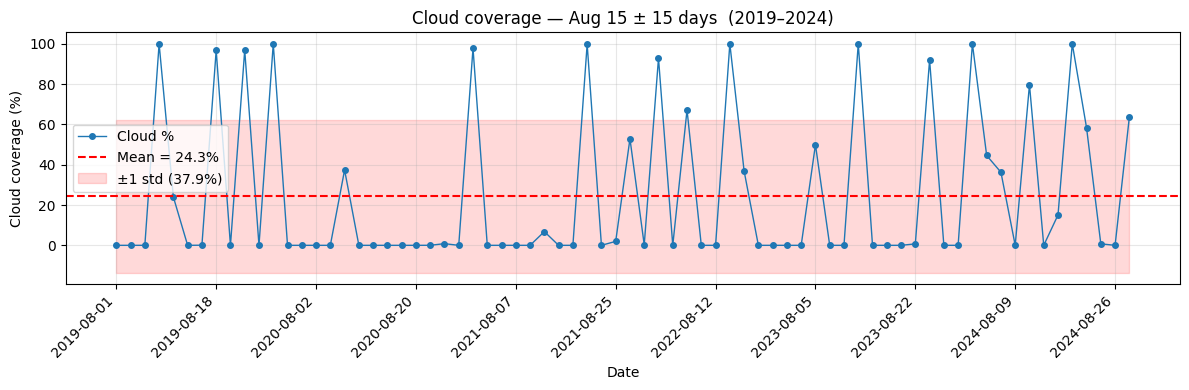

In [6]:
api.plot_time_series(target, window_days=15)

## 4. Mapa interactivo (bonus)

In [21]:
m = api.visualize(target, n=3, window_days=15)

# 5. Analisis Interactivo

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create UI elements
date_picker = widgets.DatePicker(description='Target Date', value=datetime(2024, 1, 15))
window_slider = widgets.IntSlider(value=15, min=5, max=30, step=1, description='Window (± Days):')
threshold_slider = widgets.FloatSlider(value=20.0, min=5.0, max=50.0, step=1.0, description='Max Clouds %:')
button = widgets.Button(description='Run Analysis', button_style='primary')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        target_dt = datetime.combine(date_picker.value, datetime.min.time())
        
        prob = api.get_cloud_probability(target_dt, window_days=window_slider.value)
        usable = api.get_usable_image_probability(target_dt, window_days=window_slider.value, max_clouds=threshold_slider.value)
        
        print(f"--- Results for {target_dt.strftime('%d %b')} ---")
        print(f"  Media : {prob['mean']:.1f}%")
        print(f"  Std   : {prob['std']:.1f}%")
        print(f"  P25 (Días más despejados) : {prob['p25']:.1f}%")
        print(f"  Mediana (Lo típico)       : {prob['median']:.1f}%")
        print(f"  P75 (Días más nublados)   : {prob['p75']:.1f}%")
        print(f"  Prob. de imagen útil      : {usable:.1f}%")
        print(f"Nubosidad esperada el {target.strftime('%d %b')}:")

        print(f"  Prob. de imagen útil (≤20% nubes): {usable_prob:.1f}%")

button.on_click(on_button_clicked)

# Display the UI
display(widgets.VBox([date_picker, window_slider, threshold_slider, button, output]))

# 6. Probabilidades Anuales

Generating annual cloud profile...


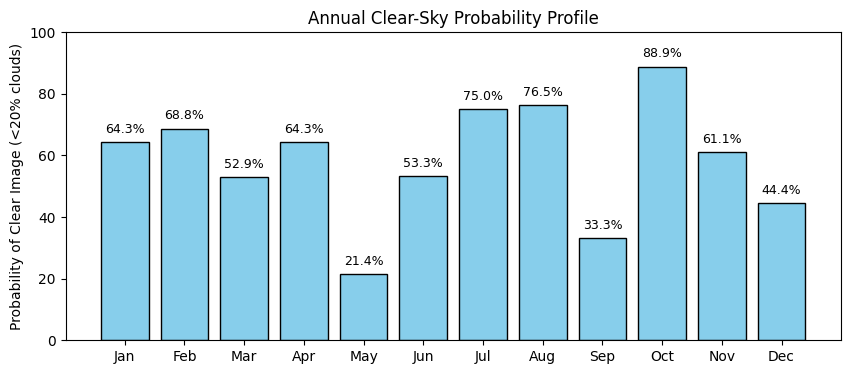

In [24]:
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
usable_probs = []

print("Generating annual cloud profile...")
for month in range(1, 13):
    test_date = datetime(2023, month, 3)
    prob = api.get_usable_image_probability(test_date, window_days=3, max_clouds=20.0)
    usable_probs.append(prob)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(months, usable_probs, color='skyblue', edgecolor='black')
ax.set_ylabel("Probability of Clear Image (<20% clouds)")
ax.set_title("Annual Clear-Sky Probability Profile")
ax.set_ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9)

plt.show()